Найден файл: G:/SABER_L2A\2012\197\SABER_L2A_2012197_57428_02.07.nc

Загрузка данных из файла...
Дата: 15.07.2012
Профилей: 98, высотных уровней: 400
Загружено точек: 24883
Диапазон времени: 2012-07-15 01:17:53 - 2012-07-15 02:54:54
Точек в траектории: 249

Центральное время для детальной карты: 2012-07-15 01:41:00

Вычисление точек профилей...
Режим: диапазон 90.0-110.0 км
Точки на средней высоте: 100.0 км
Найдено точек профилей: 143

Границы детальной карты: {'lat_min': 0.0, 'lat_max': 70.0, 'lon_min': 0.0, 'lon_max': 120.0}
Временное окно детальной карты: 2012-07-15 01:26:00 - 2012-07-15 01:56:00
Точек в детальном окне: 7620

Создание графика...


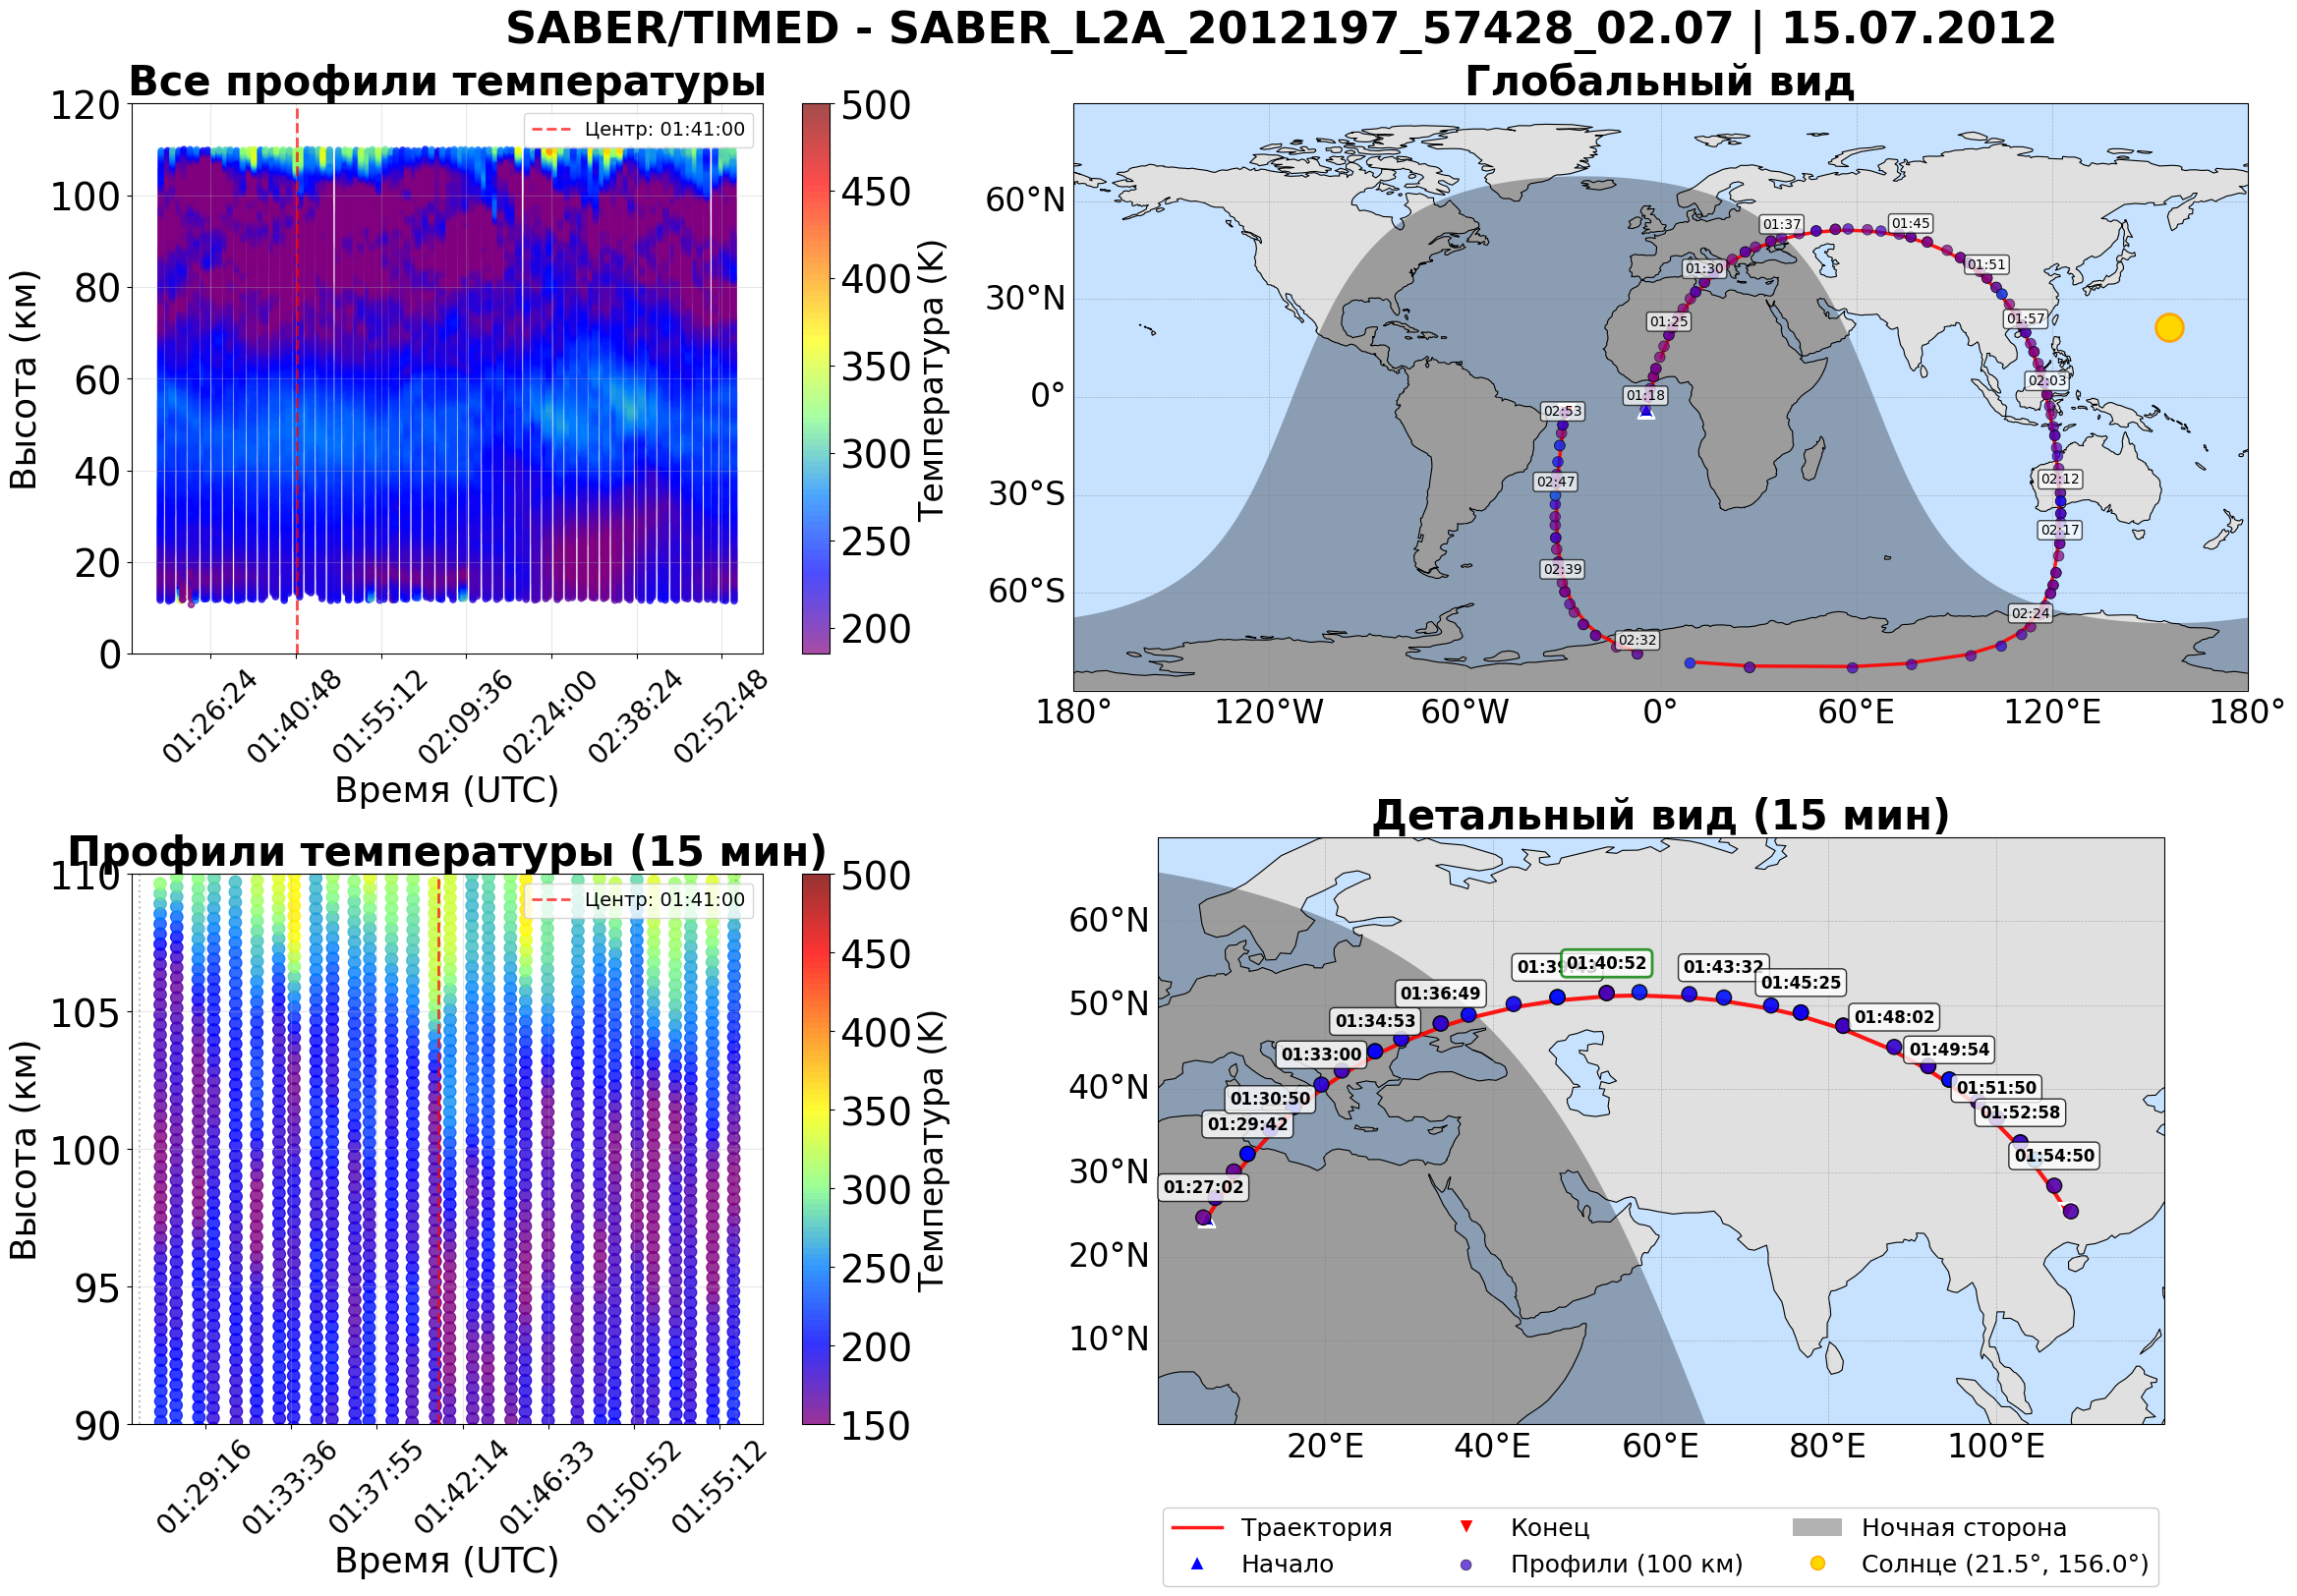


✓ График сохранен: C:/Users/Maks/Desktop/Jupyter/temp_profiles/single\SABER_SABER_L2A_2012197_57428_02.07_detailed_20120715_014100.png

ОБРАБОТКА ЗАВЕРШЕНА


In [7]:
import xarray as xr
import pandas as pd
import numpy as np
import datetime as dt
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.dates import DateFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.feature.nightshade as nightshade
import pysolar.solar as solar

# ============= НАСТРОЙКИ ШРИФТОВ =============
plt.rcParams['xtick.labelsize'] = 20    # Цифры на оси X
plt.rcParams['ytick.labelsize'] = 28    # Цифры на оси Y
plt.rcParams['legend.fontsize'] = 14    # Легенда
plt.rcParams['axes.labelsize'] = 24
plt.rcParams['font.size'] = 24

# ============= РУЧНОЙ ВЫБОР ФАЙЛА =============
file_year = 2012
saber_file = 'SABER_L2A_2012197_57428_02.07'  # Имя файла без .nc
target_altitude = 81.7  # Высота для фильтрации траектории (км)
altitude_tolerance = 0.5  # Допустимое отклонение от целевой высоты в км

temp_min_loc=150 #185 #210 #215 #150
temp_max_loc=500 #280 #230 #225 #500

temp_min_glob=185 #185 #210 #185 #180
temp_max_glob=500 #280 #230 #245 #500

# ============= НАСТРОЙКИ ТОЧЕК ПРОФИЛЕЙ =============
# Режим: 'single' - одна высота, 'range' - диапазон
profile_point_mode = 'range'  # 'single' или 'range'

# Для режима 'single' 
single_point_height = 17.5  # км, высота для отображения точек
single_median_max = 25.0    # км, макс высота для расчета медианы

# Для режима 'range'
range_min = 90.0    # км, мин высота для расчета
range_max = 110.0    # км, макс высота для расчета

# ============= НАСТРОЙКИ ДЕТАЛЬНОЙ КАРТЫ =============
# Режим детального вида: 'manual' - ручной, 'auto' - авто (по траектории)
detail_mode = 'manual'  # 'manual' или 'auto'

# Для ручного режима - задайте границы детальной карты
detail_region = {
    'lat_min': 0.0,   # Минимальная широта
    'lat_max': 70.0,   # Максимальная широта
    'lon_min': 0.0,   # Минимальная долгота
    'lon_max': 120.0    # Максимальная долгота
}

# Временное окно для детальной карты (в минутах относительно центра пролета)
time_window_minutes = 15  # ±15 минут от центра пролета

# Центральное время для детальной карты (если None - берется середина пролета)
center_time_manual = dt.datetime(2012, 7, 15, 1, 41, 0)  # Пример: dt.datetime(2014, 7, 28, 12, 0, 0)

# ============= НАСТРОЙКИ ГРОЗОВЫХ РАЗРЯДОВ (опционально) =============
# Если хотите показать разряды на карте для сравнения
show_lightning = False  # Включить отображение грозовых разрядов
lightning_file = None   # Путь к файлу с разрядами (если есть)

# Пути к файлам
base_satellite_directory = 'G:/SABER_L2A'
output_plot_dir = f'C:/Users/Maks/Desktop/Jupyter/temp_profiles/single'

# Создаем папку для сохранения
os.makedirs(output_plot_dir, exist_ok=True)

# ============= ФУНКЦИИ =============
def yyddd_to_date(yyddd):
    yyddd_str = str(int(yyddd))
    year = int(yyddd_str[:4])
    day_of_year = int(yyddd_str[4:])
    return dt.datetime(year, 1, 1) + dt.timedelta(days=day_of_year - 1)

def calculate_solar_position(utc_time):
    if utc_time.tzinfo is None:
        utc_time = utc_time.replace(tzinfo=dt.timezone.utc)
    
    best_lat = 0
    best_lon = 0
    max_alt = -90
    
    for lat in range(-90, 91, 10):
        for lon in range(-180, 180, 10):
            try:
                alt = solar.get_altitude(float(lat), float(lon), utc_time)
                if alt > max_alt:
                    max_alt = alt
                    best_lat = lat
                    best_lon = lon
            except Exception:
                continue
    
    for lat in np.arange(best_lat - 5, best_lat + 5, 0.5):
        for lon in np.arange(best_lon - 5, best_lon + 5, 0.5):
            try:
                alt = solar.get_altitude(float(lat), float(lon), utc_time)
                if alt > max_alt:
                    max_alt = alt
                    best_lat = lat
                    best_lon = lon
            except Exception:
                continue
    
    sun_lon = best_lon if best_lon >= 0 else best_lon + 360
    sun_lat = best_lat
    return sun_lon, sun_lat

# ============= ПОИСК ФАЙЛА =============
file_parts = saber_file.split('_')
yyddd = file_parts[2]
day = yyddd[-3:]

possible_paths = [
    os.path.join(base_satellite_directory, str(file_year), day, f"{saber_file}.nc"),
    os.path.join(base_satellite_directory, str(file_year), f"{saber_file}.nc"),
]

nc_file_path = None
for path in possible_paths:
    if os.path.exists(path):
        nc_file_path = path
        print(f"Найден файл: {path}")
        break

if nc_file_path is None:
    raise FileNotFoundError(f"Файл не найден: {saber_file}.nc")

# ============= ЗАГРУЗКА ДАННЫХ =============
print(f"\nЗагрузка данных из файла...")

ds = xr.open_dataset(nc_file_path)

time_data = ds['time'].values
ktemp_data = ds['ktemp'].values
lat_data = ds['tplatitude'].values
lon_data = ds['tplongitude'].values
alt_data = ds['tpaltitude'].values
date_value = yyddd_to_date(ds['date'].values[0])

print(f"Дата: {date_value.strftime('%d.%m.%Y')}")
print(f"Профилей: {len(time_data)}, высотных уровней: {len(ds['altitude'])}")

ds.close()

# Собираем все данные
all_profiles_list = []

for row_idx in range(len(time_data)):
    temps = ktemp_data[row_idx]
    alts = alt_data[row_idx]
    lats = lat_data[row_idx]
    lons = lon_data[row_idx]
    times = time_data[row_idx]
    
    valid_mask = ~np.isnan(temps)
    if not valid_mask.any():
        continue
    
    valid_indices = np.where(valid_mask)[0]
    
    for idx in valid_indices:
        time_ms = float(times[idx])
        point_time = date_value + dt.timedelta(milliseconds=time_ms)
        point_time = pd.Timestamp(point_time).floor('s')
        
        all_profiles_list.append({
            'datetime': point_time,
            'altitude_km': float(alts[idx]),
            'temperature_K': float(temps[idx]),
            'lat': float(lats[idx]),
            'lon': float(lons[idx]),
        })

all_profiles_df = pd.DataFrame(all_profiles_list)
all_profiles_df = all_profiles_df.sort_values(['datetime', 'altitude_km']).reset_index(drop=True)

print(f"Загружено точек: {len(all_profiles_df)}")
print(f"Диапазон времени: {all_profiles_df['datetime'].min()} - {all_profiles_df['datetime'].max()}")

# ===== ФИЛЬТРАЦИЯ ПО ВЫСОТЕ ДЛЯ ТРАЕКТОРИИ =====
all_profiles_df['alt_diff'] = abs(all_profiles_df['altitude_km'] - target_altitude)
satellite_df = all_profiles_df[all_profiles_df['alt_diff'] <= altitude_tolerance].copy()

if len(satellite_df) == 0:
    closest_points = all_profiles_df.loc[all_profiles_df.groupby('datetime')['alt_diff'].idxmin()]
    satellite_df = closest_points.copy()
    print(f"\nИспользуются ближайшие по высоте точки")

# Траектория
traj_df = satellite_df.sort_values('datetime').copy()
print(f"Точек в траектории: {len(traj_df)}")

# Определяем центральное время для детальной карты
if center_time_manual is not None:
    center_time = center_time_manual
else:
    # Берем середину временного диапазона траектории
    center_time = all_profiles_df['datetime'].min() + (all_profiles_df['datetime'].max() - all_profiles_df['datetime'].min())/2
    center_time = pd.Timestamp(center_time)

print(f"\nЦентральное время для детальной карты: {center_time}")

# ===== ПОЛОЖЕНИЕ СОЛНЦА =====
sun_lon, sun_lat = calculate_solar_position(center_time)

# ===== ЦВЕТОВАЯ КАРТА =====
colors = [(0.5, 0.0, 0.5), (0, 0, 1), (0, 0.5, 1), (0.5,1,0.5), 
          (1, 1, 0), (1, 0.5, 0), (1, 0, 0), (0.5, 0, 0)]
custom_cmap = LinearSegmentedColormap.from_list("custom_coolwarm", colors, N=100)

# ===== ТОЧКИ ПРОФИЛЕЙ =====
print(f"\nВычисление точек профилей...")

if profile_point_mode == 'single':
    target_point_height = single_point_height
    median_max = single_median_max
    print(f"Режим: одна высота {target_point_height} км, медиана 0-{median_max} км")
else:
    target_point_height = (range_min + range_max) / 2
    print(f"Режим: диапазон {range_min}-{range_max} км")
    print(f"Точки на средней высоте: {target_point_height:.1f} км")

profile_points_list = []

for dt_time in all_profiles_df['datetime'].unique():
    profile_data = all_profiles_df[all_profiles_df['datetime'] == dt_time]
    
    if profile_point_mode == 'single':
        height_diff = abs(profile_data['altitude_km'] - target_point_height)
        if height_diff.min() <= 1.0:
            point_idx = height_diff.idxmin()
            point_lat = profile_data.loc[point_idx, 'lat']
            point_lon = profile_data.loc[point_idx, 'lon']
            temps_range = profile_data[profile_data['altitude_km'] <= median_max]['temperature_K']
        else:
            continue
    else:
        height_diff = abs(profile_data['altitude_km'] - target_point_height)
        if height_diff.min() <= 2.0:
            point_idx = height_diff.idxmin()
            point_lat = profile_data.loc[point_idx, 'lat']
            point_lon = profile_data.loc[point_idx, 'lon']
            temps_range = profile_data[
                (profile_data['altitude_km'] >= range_min) & 
                (profile_data['altitude_km'] <= range_max)
            ]['temperature_K']
        else:
            continue
    
    if len(temps_range) > 0:
        median_temp = temps_range.median()
        profile_points_list.append({
            'datetime': dt_time,
            'lat': point_lat,
            'lon': point_lon,
            'median_temp': median_temp
        })

profile_points_df = pd.DataFrame(profile_points_list)
print(f"Найдено точек профилей: {len(profile_points_df)}")

# ===== ОПРЕДЕЛЕНИЕ ГРАНИЦ ДЛЯ ДЕТАЛЬНОЙ КАРТЫ =====
if detail_mode == 'auto':
    # Автоматически определяем границы по траектории
    if len(traj_df) > 0:
        # Добавляем отступ 20%
        lon_min = traj_df['lon'].min()
        lon_max = traj_df['lon'].max()
        lat_min = traj_df['lat'].min()
        lat_max = traj_df['lat'].max()
        
        lon_range = lon_max - lon_min
        lat_range = lat_max - lat_min
        
        lon_padding = lon_range * 0.3
        lat_padding = lat_range * 0.3
        
        detail_region = {
            'lat_min': lat_min - lat_padding,
            'lat_max': lat_max + lat_padding,
            'lon_min': lon_min - lon_padding,
            'lon_max': lon_max + lon_padding
        }
    else:
        print("Предупреждение: Нет данных траектории для авто-определения границ")
        detail_mode = 'manual'

print(f"\nГраницы детальной карты: {detail_region}")

# Временное окно для детальной карты
time_window_start = center_time - dt.timedelta(minutes=time_window_minutes)
time_window_end = center_time + dt.timedelta(minutes=time_window_minutes)

print(f"Временное окно детальной карты: {time_window_start} - {time_window_end}")

# Данные для детальной карты
detailed_data = all_profiles_df[
    (all_profiles_df['datetime'] >= time_window_start) & 
    (all_profiles_df['datetime'] <= time_window_end)
].copy()
print(f"Точек в детальном окне: {len(detailed_data)}")

# ===== СОЗДАНИЕ ГРАФИКА =====
print(f"\nСоздание графика...")

fig = plt.figure(figsize=(26, 16))
gs = fig.add_gridspec(2, 2, width_ratios=[0.4, 0.6], wspace=0.15, hspace=0.4)
gs_right = gs[:, 1].subgridspec(2, 1, hspace=0.25)

# ----- ЛЕВЫЕ ГРАФИКИ: ПРОФИЛИ -----
# Верхний левый график - все профили
ax1_top = plt.subplot(gs[0, 0])

scatter_top = ax1_top.scatter(all_profiles_df['datetime'], 
                             all_profiles_df['altitude_km'], 
                             c=all_profiles_df['temperature_K'], 
                             cmap=custom_cmap, s=20, alpha=0.7,
                             vmin=temp_min_glob, vmax=temp_max_glob)

# Отмечаем центральное время на графике
ax1_top.axvline(x=center_time, color='red', linestyle='--', linewidth=2, alpha=0.7,
               label=f'Центр: {center_time.strftime("%H:%M:%S")}')

ax1_top.xaxis.set_major_formatter(DateFormatter('%H:%M:%S'))
ax1_top.xaxis.set_major_locator(plt.MaxNLocator(8))
ax1_top.tick_params(axis='x', rotation=45)
ax1_top.grid(True, alpha=0.3)
ax1_top.set_xlabel('Время (UTC)', fontsize=26)
ax1_top.set_ylabel('Высота (км)', fontsize=26)
ax1_top.set_ylim(0, 120)
ax1_top.set_title('Все профили температуры', fontsize=30, fontweight='bold')
ax1_top.legend(loc='upper right')

cbar_top = plt.colorbar(scatter_top, ax=ax1_top)
cbar_top.set_label('Температура (K)', fontsize=24)

# Нижний левый график - детальное окно
ax1_bottom = plt.subplot(gs[1, 0])

# Фильтруем данные для детального окна по высоте (10-30 км для наглядности)
window_profiles_df = detailed_data.copy()

scatter_bottom = ax1_bottom.scatter(window_profiles_df['datetime'], 
                                   window_profiles_df['altitude_km'], 
                                   c=window_profiles_df['temperature_K'], 
                                   cmap=custom_cmap, s=80, alpha=0.8,
                                   vmin=temp_min_loc, vmax=temp_max_loc)

ax1_bottom.axvline(x=center_time, color='red', linestyle='--', linewidth=2, alpha=0.7,
                  label=f'Центр: {center_time.strftime("%H:%M:%S")}')

# Отображаем границы временного окна
ax1_bottom.axvline(x=time_window_start, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
ax1_bottom.axvline(x=time_window_end, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)

ax1_bottom.xaxis.set_major_formatter(DateFormatter('%H:%M:%S'))
ax1_bottom.xaxis.set_major_locator(plt.MaxNLocator(8))
ax1_bottom.tick_params(axis='x', rotation=45)
ax1_bottom.grid(True, alpha=0.3)
ax1_bottom.set_xlabel('Время (UTC)', fontsize=26)
ax1_bottom.set_ylabel('Высота (км)', fontsize=26)
ax1_bottom.set_ylim(90, 110)
ax1_bottom.set_title(f'Профили температуры ({time_window_minutes} мин)', fontsize=30, fontweight='bold')
ax1_bottom.legend(loc='upper right')

cbar_bottom = plt.colorbar(scatter_bottom, ax=ax1_bottom)
cbar_bottom.set_label('Температура (K)', fontsize=24)

# ===== ПРАВЫЕ ГРАФИКИ: КАРТЫ =====
ax2_top = fig.add_subplot(gs_right[0], projection=ccrs.PlateCarree())
ax2_bottom = fig.add_subplot(gs_right[1], projection=ccrs.PlateCarree())

# Глобальная карта
ax2_top.add_feature(nightshade.Nightshade(center_time, alpha=0.3, color='black'))
ax2_top.plot(sun_lon, sun_lat, 'o', color='gold', markersize=20, 
            markeredgecolor='orange', markeredgewidth=2, transform=ccrs.PlateCarree(), zorder=5)
ax2_top.add_feature(cfeature.LAND, facecolor='#e0e0e0')
ax2_top.add_feature(cfeature.OCEAN, facecolor='#c6e2ff')
ax2_top.add_feature(cfeature.COASTLINE, linewidth=0.8)

gl = ax2_top.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), 
                       linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# ===== ТРАЕКТОРИЯ НА ГЛОБАЛЬНОЙ КАРТЕ =====
if len(traj_df) > 0:
    traj_unique = traj_df.groupby('datetime').agg({
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index().sort_values('datetime')
    
    lons_fixed = traj_unique['lon'].values
    lons_fixed = np.where(lons_fixed < 0, lons_fixed + 360, lons_fixed)
    threshold = 180
    segments = []
    current_segment = []
    
    for i in range(len(lons_fixed)):
        if len(current_segment) == 0:
            current_segment.append(i)
        else:
            prev_idx = current_segment[-1]
            if abs(lons_fixed[i] - lons_fixed[prev_idx]) > threshold:
                segments.append(current_segment)
                current_segment = [i]
            else:
                current_segment.append(i)
    if current_segment:
        segments.append(current_segment)
    
    for seg in segments:
        ax2_top.plot(traj_unique['lon'].iloc[seg], traj_unique['lat'].iloc[seg], 
                color='red', linewidth=2.5, label='Траектория' if seg is segments[0] else '',
                alpha=0.9, zorder=3, transform=ccrs.PlateCarree())
    
    ax2_top.plot(traj_unique['lon'].iloc[0], traj_unique['lat'].iloc[0], '^', color='blue', 
            markersize=12, markeredgecolor='white', markeredgewidth=1.5,
            label='Начало', transform=ccrs.PlateCarree(), zorder=6)
    ax2_top.plot(traj_unique['lon'].iloc[-1], traj_unique['lat'].iloc[-1], 'v', color='red', 
            markersize=12, markeredgecolor='white', markeredgewidth=1.5,
            label='Конец', transform=ccrs.PlateCarree(), zorder=6)

# ===== ТОЧКИ ПРОФИЛЕЙ НА ГЛОБАЛЬНОЙ КАРТЕ =====
if len(profile_points_df) > 0:
    scatter_points_global = ax2_top.scatter(
        profile_points_df['lon'], 
        profile_points_df['lat'],
        c=profile_points_df['median_temp'],
        cmap=custom_cmap,
        s=60,
        marker='o',
        edgecolor='black',
        linewidth=0.5,
        alpha=0.7,
        vmin=temp_min_glob, vmax=temp_max_glob,
        transform=ccrs.PlateCarree(),
        zorder=15,
        label=f'Профили ({target_point_height:.0f} км)'
    )
    
    # Метки времени каждые 10 точек
    label_indices = np.arange(0, len(profile_points_df), 10)
    
    for idx in label_indices:
        if idx < len(profile_points_df):
            row = profile_points_df.iloc[idx]
            time_str = row['datetime'].strftime('%H:%M')
            ax2_top.text(
                row['lon'], row['lat'] + 2.0,
                time_str,
                fontsize=10,
                color='black',
                weight='normal',
                ha='center',
                va='bottom',
                transform=ccrs.PlateCarree(),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7),
                zorder=16
            )

ax2_top.set_global()
ax2_top.set_title('Глобальный вид', fontsize=30, fontweight='bold')

# ===== ДЕТАЛЬНАЯ КАРТА =====
ax2_bottom.add_feature(nightshade.Nightshade(center_time, alpha=0.3, color='black'))
ax2_bottom.add_feature(cfeature.LAND, facecolor='#e0e0e0')
ax2_bottom.add_feature(cfeature.OCEAN, facecolor='#c6e2ff')
ax2_bottom.add_feature(cfeature.COASTLINE, linewidth=0.8)

gl_detailed = ax2_bottom.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), 
                                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl_detailed.top_labels = False
gl_detailed.right_labels = False

# Траектория на детальной карте (только в пределах временного окна)
traj_detailed = satellite_df[
    (satellite_df['datetime'] >= time_window_start) & 
    (satellite_df['datetime'] <= time_window_end)
].copy()

if len(traj_detailed) > 0:
    traj_detailed_unique = traj_detailed.groupby('datetime').agg({
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index().sort_values('datetime')
    
    ax2_bottom.plot(traj_detailed_unique['lon'], traj_detailed_unique['lat'], 
                   color='red', linewidth=3, alpha=0.9, zorder=3, 
                   transform=ccrs.PlateCarree(), label='Траектория (детально)')
    
    # Начало и конец детального участка
    ax2_bottom.plot(traj_detailed_unique['lon'].iloc[0], traj_detailed_unique['lat'].iloc[0], 
                   '^', color='blue', markersize=12, markeredgecolor='white', 
                   markeredgewidth=1.5, transform=ccrs.PlateCarree(), zorder=6)
    ax2_bottom.plot(traj_detailed_unique['lon'].iloc[-1], traj_detailed_unique['lat'].iloc[-1], 
                   'v', color='red', markersize=12, markeredgecolor='white', 
                   markeredgewidth=1.5, transform=ccrs.PlateCarree(), zorder=6)

# Точки профилей на детальной карте
detailed_points = profile_points_df[
    (profile_points_df['datetime'] >= time_window_start) & 
    (profile_points_df['datetime'] <= time_window_end)
].copy()

if len(detailed_points) > 0:
    scatter_points_detailed = ax2_bottom.scatter(
        detailed_points['lon'], 
        detailed_points['lat'],
        c=detailed_points['median_temp'],
        cmap=custom_cmap,
        s=120,
        marker='o',
        edgecolor='black',
        linewidth=1,
        alpha=0.9,
        vmin=temp_min_loc, vmax=temp_max_loc,
        transform=ccrs.PlateCarree(),
        zorder=15,
        label=f'Профили ({target_point_height:.0f} км)'
    )
    
    # Метки времени для детальной карты (каждые 2-3 точки)
    label_indices_detailed = np.arange(0, len(detailed_points), 3)
    
    for idx in label_indices_detailed:
        if idx < len(detailed_points):
            row = detailed_points.iloc[idx]
            time_str = row['datetime'].strftime('%H:%M:%S')
            
            # Для центральной точки - зеленая рамка
            time_diff = abs(row['datetime'] - center_time)
            if time_diff.total_seconds() < 30:  # В пределах 30 секунд от центра
                bbox_props = dict(boxstyle='round,pad=0.3', facecolor='white', 
                                  edgecolor='green', linewidth=2, alpha=0.8)
            else:
                bbox_props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
            
            ax2_bottom.text(
                row['lon'], row['lat'] + 2.5,
                time_str,
                fontsize=12,
                color='black',
                weight='bold',
                ha='center',
                va='bottom',
                transform=ccrs.PlateCarree(),
                bbox=bbox_props,
                zorder=16
            )

# Устанавливаем границы детальной карты
ax2_bottom.set_xlim(detail_region['lon_min'], detail_region['lon_max'])
ax2_bottom.set_ylim(detail_region['lat_min'], detail_region['lat_max'])
ax2_bottom.set_title(f'Детальный вид ({time_window_minutes} мин)', 
                     fontsize=30, fontweight='bold')

# Легенда для карт
handles, labels = ax2_top.get_legend_handles_labels()
sun_legend = [
    Patch(facecolor='black', alpha=0.3, label='Ночная сторона'),
    Line2D([0], [0], marker='o', color='gold', markersize=10, 
           markeredgecolor='orange', linestyle='None',
           label=f'Солнце ({sun_lat:.1f}°, {sun_lon:.1f}°)')
]

ax2_bottom.legend(handles + sun_legend, 
                 [h.get_label() if hasattr(h, 'get_label') else h for h in handles + sun_legend],
                 loc='upper center', bbox_to_anchor=(0.5, -0.12),
                 fontsize=18, ncol=3, framealpha=1.0)

# Информационная панель
if profile_point_mode == 'single':
    info_text = f'Высота траектории: {target_altitude:.1f} км\n'
    info_text += f'Точки профилей: {target_point_height:.0f} км\n'
    info_text += f'Медиана температур: 0-{median_max} км\n'
else:
    info_text = f'Высота траектории: {target_altitude:.1f} км\n'
    info_text += f'Точки профилей: ср. {target_point_height:.0f} км\n'
    info_text += f'Медиана температур: {range_min}-{range_max} км\n'

info_text += f'Детальное окно: ±{time_window_minutes} мин\n'
info_text += f'Центр: {center_time.strftime("%H:%M:%S")}\n'
info_text += f'Границы: {detail_region["lat_min"]:.1f}°-{detail_region["lat_max"]:.1f}°, '
info_text += f'{detail_region["lon_min"]:.1f}°-{detail_region["lon_max"]:.1f}°'

#ax2_bottom.text(0.02, -0.12, info_text, transform=ax2_top.transAxes, fontsize=10,
                #fontweight='bold', verticalalignment='top',
                #bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

# Заголовок
fig.suptitle(f'SABER/TIMED - {saber_file} | {date_value.strftime("%d.%m.%Y")}', 
             fontsize=32, fontweight='bold', y=0.98)

plt.subplots_adjust(left=0.05, right=0.88, bottom=0.08, top=0.92, wspace=0.15)

# Сохранение
filename = f'SABER_{saber_file}_detailed_{center_time.strftime("%Y%m%d_%H%M%S")}.png'
plot_path = os.path.join(output_plot_dir, filename)

plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"\n✓ График сохранен: {plot_path}")
print(f"\n{'='*60}")
print("ОБРАБОТКА ЗАВЕРШЕНА")